Name: Se Rang Seo (Simon)

Professor: Dr. Romanowsky

Course: Phys255 Machine Learning

# About

The topic I am going to choose is going to be medical science. I’m going to use this article. This article is a statistical study done on German patients aged 65 and above with chronic diseases such as: hypertension, diabetes, cancer, heart failure, and so on. There are a total of around 840,000 patients: 42% male and 56% female. The reason for this study was to analyze the general public’s health in elderly patients in Germany while the conclusion they found was that chronic disease was high for German elders and that hypertension was the highest chronic disease for 25% of the patients.

https://datadryad.org/dataset/doi:10.5061/dryad.qh0h1#usage

https://journals.publisso.de/en/journals/gms/volume14/000230


### Chronic Diseases:

$\bf{Hypertension}$ or High Blood Pressure: a common condition where the force of blood against the artery walls is consistently too high. This can lead to serious health issues, including heart disease and stroke

$\bf{CHD}$ (Coronary Heart Disease) or Ischemic Heart Diease: a type of heart disease involving the reduction of blood flow to the cardiac muscle due to a build-up of atheromatous plaque in the arteries of the heart.

$\bf{Lipid}$ Disorder: the most common type of heart disease and the leading cause of death in the United States. It occurs when the coronary arteries become narrowed or blocked due to the buildup of atheromatous plaque, which reduces blood flow to the heart muscle

$\bf{Stroke}$: the blood supply to part of the brain is blocked or reduced

$\bf{Heart Failure}$ or Congestive Heart Failure: a chronic condition where the heart muscle is unable to pump enough blood to meet the body's needs for blood and oxygen. 

$\bf{Cancer}$: a disease in which some of the body’s cells grow uncontrollably and spread to other parts of the body

$\bf{Diabetes}$: a condition that happens when your blood sugar (glucose) is too high. It develops when your pancreas doesn’t make enough insulin or any at all, or when your body isn’t responding to the effects of insulin properly.

$\bf{COPD}$ (Chronic Obstructive Pulmonary Disease): a progressive lung disease that makes it difficult to breathe, primarily caused by long-term exposure to irritants like cigarette smoke and air pollution.

$\bf{Osteoporosis}$: a bone disease characterized by weak and fragile bones, increasing the risk of fractures

$\bf{Chronic Kidney Disease}$: your kidneys slowly get damaged and can't do important jobs like removing waste and keeping blood pressure normal

# Plan
I'm going to focus on the correlation between age and strokes and the chronic diseases and strokes.

1. Data analysis: confusion correlation, pair plot, and violin plot. Feature engineer (if necessary)
2. Supervised learning - Classifier: logistic regressor, knn, SVM, GXboost, and random forest.
3. Unsupervised learning - Clustering: K-Means, Hierarchical, and Gaussian Mixture

Supervised learning is used to detect patients with strokes using age and chronic diseases focusing on Recall.

Unsupervised learning is to identify groups of patients who are more likely to get a stroke for further care.

# Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.metrics import silhouette_samples

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Cluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

#pip install pandas openpyxl
#pip install xlrd

# Dataset

In [56]:
dataset = pd.read_excel('cd2014.xls')

In [57]:
dataset

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1,80,1,1,1,0,0,0,0,0,0,0
9996,9997,0,67,1,0,1,0,0,0,0,0,0,0
9997,9998,0,90,0,0,0,0,0,0,0,0,0,0
9998,9999,0,67,0,0,0,0,0,1,0,0,0,0


### Gender 
1 is male and 0 is female

1 is yes and 0 is no

In [58]:
dataset.head()

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0


I think I should drop the patient number and age. Age is not too important since we are, in general, studying elderly patients, so whether they are 70 or 95, they are elderly people.
I will also drop nulls, although I don't see any.

In [59]:
dropnaset = dataset.dropna()
dropnaset = dropnaset.drop(columns=['patient'])
binaryset = dropnaset.drop(columns=['age'])

binaryset

,male_gender,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,1,0
4,1,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,0,0,0,0,0,0,0
9996,0,1,0,1,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,1,0,0,0,0


In [60]:
setlist = [col for col in binaryset.columns]

for i in setlist:
    print(binaryset[i].value_counts())
    print(f"Ratio: {binaryset[i].value_counts()[1]/(binaryset[i].value_counts()[0]+binaryset[i].value_counts()[1])*100:.2f}%",'\n')

male_gender
0    5817
1    4183
Name: count, dtype: int64
Ratio: 41.83% 

Hypertension
1    6712
0    3288
Name: count, dtype: int64
Ratio: 67.12% 

CHD
0    7426
1    2574
Name: count, dtype: int64
Ratio: 25.74% 

Lipid_disorder
0    5880
1    4120
Name: count, dtype: int64
Ratio: 41.20% 

Stroke
0    9373
1     627
Name: count, dtype: int64
Ratio: 6.27% 

Heart_failure
0    8431
1    1569
Name: count, dtype: int64
Ratio: 15.69% 

Cancer
0    8287
1    1713
Name: count, dtype: int64
Ratio: 17.13% 

Diabetes
0    6856
1    3144
Name: count, dtype: int64
Ratio: 31.44% 

COPD
0    8711
1    1289
Name: count, dtype: int64
Ratio: 12.89% 

Osteoporosis
0    8707
1    1293
Name: count, dtype: int64
Ratio: 12.93% 

Chronic_kidney_disease
0    8699
1    1301
Name: count, dtype: int64
Ratio: 13.01% 



None of my data is balanced so I will not be using accuracy as a metric.

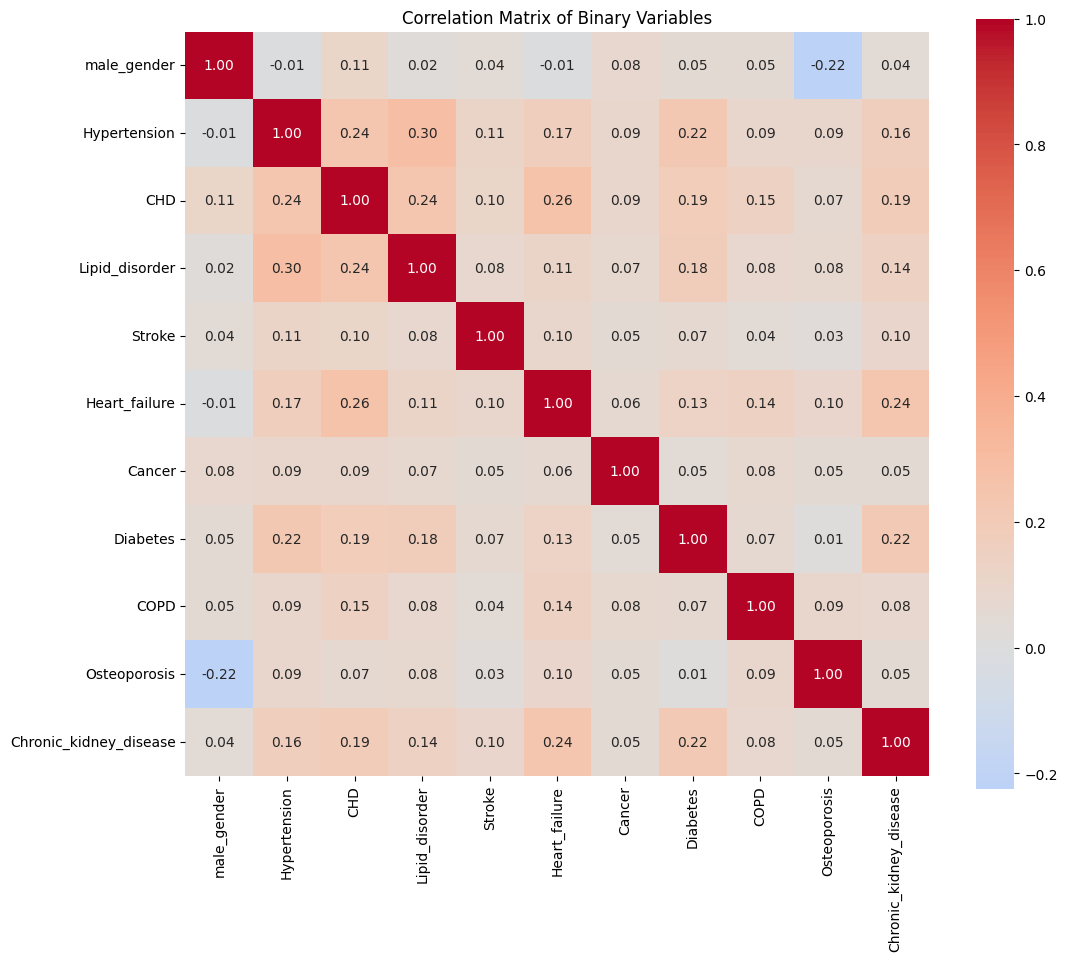

In [61]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(binaryset.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Correlation Matrix of Binary Variables')
plt.show()

Osteoporosis is less common for men.

Liquid disorder and hypertension are related.

In [62]:
# Calculate correlation matrix
corr_matrix = binaryset.corr()

# Get upper triangle of correlation matrix (excluding diagonal)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Stack and sort correlations
corr_pairs = upper_triangle.stack().sort_values(ascending=False)

# Display highest correlations
print("Highest Correlations (Top 10):")
print(corr_pairs.head(10))
print("\nLowest Correlations (Bottom 10):")
print(corr_pairs.tail(10))

Highest Correlations (Top 10):
Hypertension    Lipid_disorder            0.296536
CHD             Heart_failure             0.259815
                Lipid_disorder            0.243281
Hypertension    CHD                       0.240682
Heart_failure   Chronic_kidney_disease    0.236093
Hypertension    Diabetes                  0.222711
Diabetes        Chronic_kidney_disease    0.218944
CHD             Chronic_kidney_disease    0.191135
                Diabetes                  0.186092
Lipid_disorder  Diabetes                  0.178401
dtype: float64

Lowest Correlations (Bottom 10):
Chronic_kidney_disease  Hypertension             NaN
                        CHD                      NaN
                        Lipid_disorder           NaN
                        Stroke                   NaN
                        Heart_failure            NaN
                        Cancer                   NaN
                        Diabetes                 NaN
                        COPD           

There's certain correlations where it's about .20, so they might be too strong and can mess with the training.
Like lipid disorder and hypertension are ~ .30 while the average is around .1

# Creating Pairplot

Create a pairplot to see if I can detect stroke or cancer.

In [63]:
stroke_list = [col for col in dropnaset.columns if (col != "Stroke")]

stroke_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Heart_failure',
 'Cancer',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

In [64]:
"""sns.pairplot(dropnaset, vars=stroke_list, hue="Stroke", plot_kws={"s":15,"alpha":0.7}, corner=True)
plt.suptitle("Pairplot with target: Stroke", y=1.02)
plt.show()"""

'sns.pairplot(dropnaset, vars=stroke_list, hue="Stroke", plot_kws={"s":15,"alpha":0.7}, corner=True)\nplt.suptitle("Pairplot with target: Stroke", y=1.02)\nplt.show()'

In [65]:
cancer_list = [col for col in dropnaset.columns if (col != "Cancer")]

cancer_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Stroke',
 'Heart_failure',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

The dataset will not be balanced since I will be training 10 paramters to a single target. The metric I will be using is precision or recall. I won't be using accuracy since the dataset is not balanced

The method I would use is random forest classifier or a different classifier that's good for binary dataset.

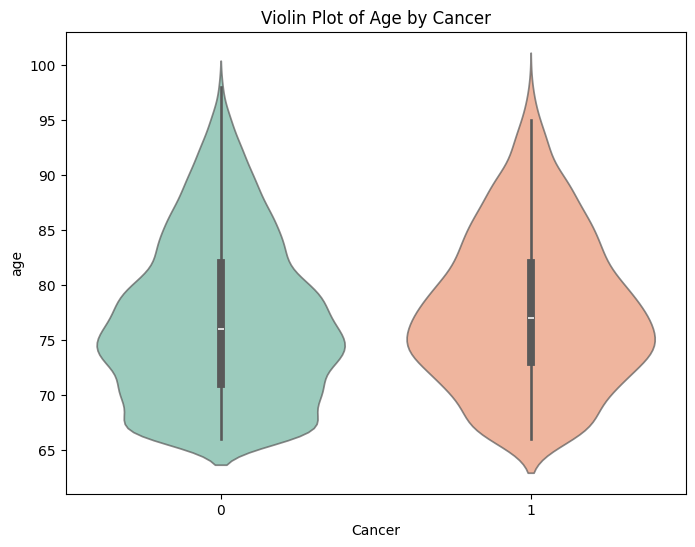

In [66]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=dropnaset, x="Cancer", y="age", 
               hue="Cancer", palette="Set2", alpha=0.7, legend=False)
plt.title("Violin Plot of Age by Cancer")
plt.show()

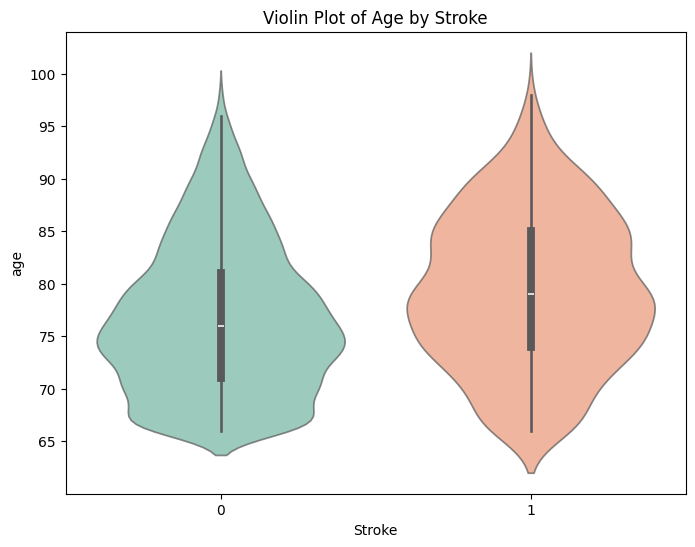

In [67]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=dropnaset, x="Stroke", y="age", 
               hue="Stroke", palette="Set2", alpha=0.7, legend=False)
plt.title("Violin Plot of Age by Stroke")
plt.show()

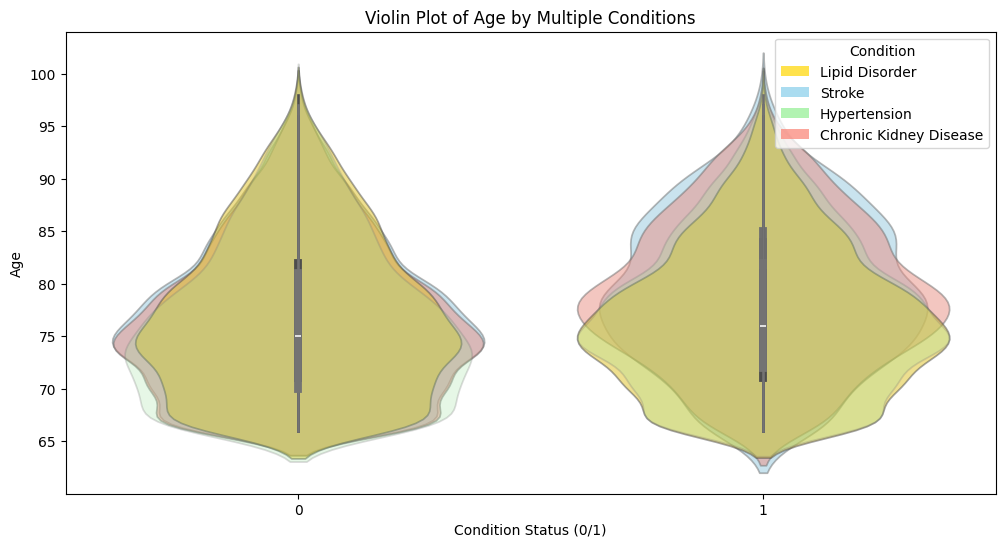

In [101]:
plt.figure(figsize=(12, 6))

# Plot all four with custom colors
stroke_plot = sns.violinplot(data=dropnaset, x="Stroke", y="age", 
                              color="skyblue", alpha=0.5, 
                              label="Stroke")
ckd_plot = sns.violinplot(data=dropnaset, x="Chronic_kidney_disease", y="age", 
                          color="salmon", alpha=0.5, 
                          label="Chronic Kidney Disease")
lipid_plot = sns.violinplot(data=dropnaset, x="Lipid_disorder", y="age", 
                            color="gold", alpha=0.5, 
                            label="Lipid Disorder")
ht_plot = sns.violinplot(data=dropnaset, x="Hypertension", y="age", 
                             color="lightgreen", alpha=0.25, 
                             label="Hypertension")
# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', alpha=0.7, label='Lipid Disorder'),
    Patch(facecolor='skyblue', alpha=0.7, label='Stroke'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Hypertension'),
    Patch(facecolor='salmon', alpha=0.7, label='Chronic Kidney Disease')
]
plt.legend(handles=legend_elements, title="Condition", loc='upper right')

plt.title("Violin Plot of Age by Multiple Conditions")
plt.xlabel("Condition Status (0/1)")
plt.ylabel("Age")
plt.show()

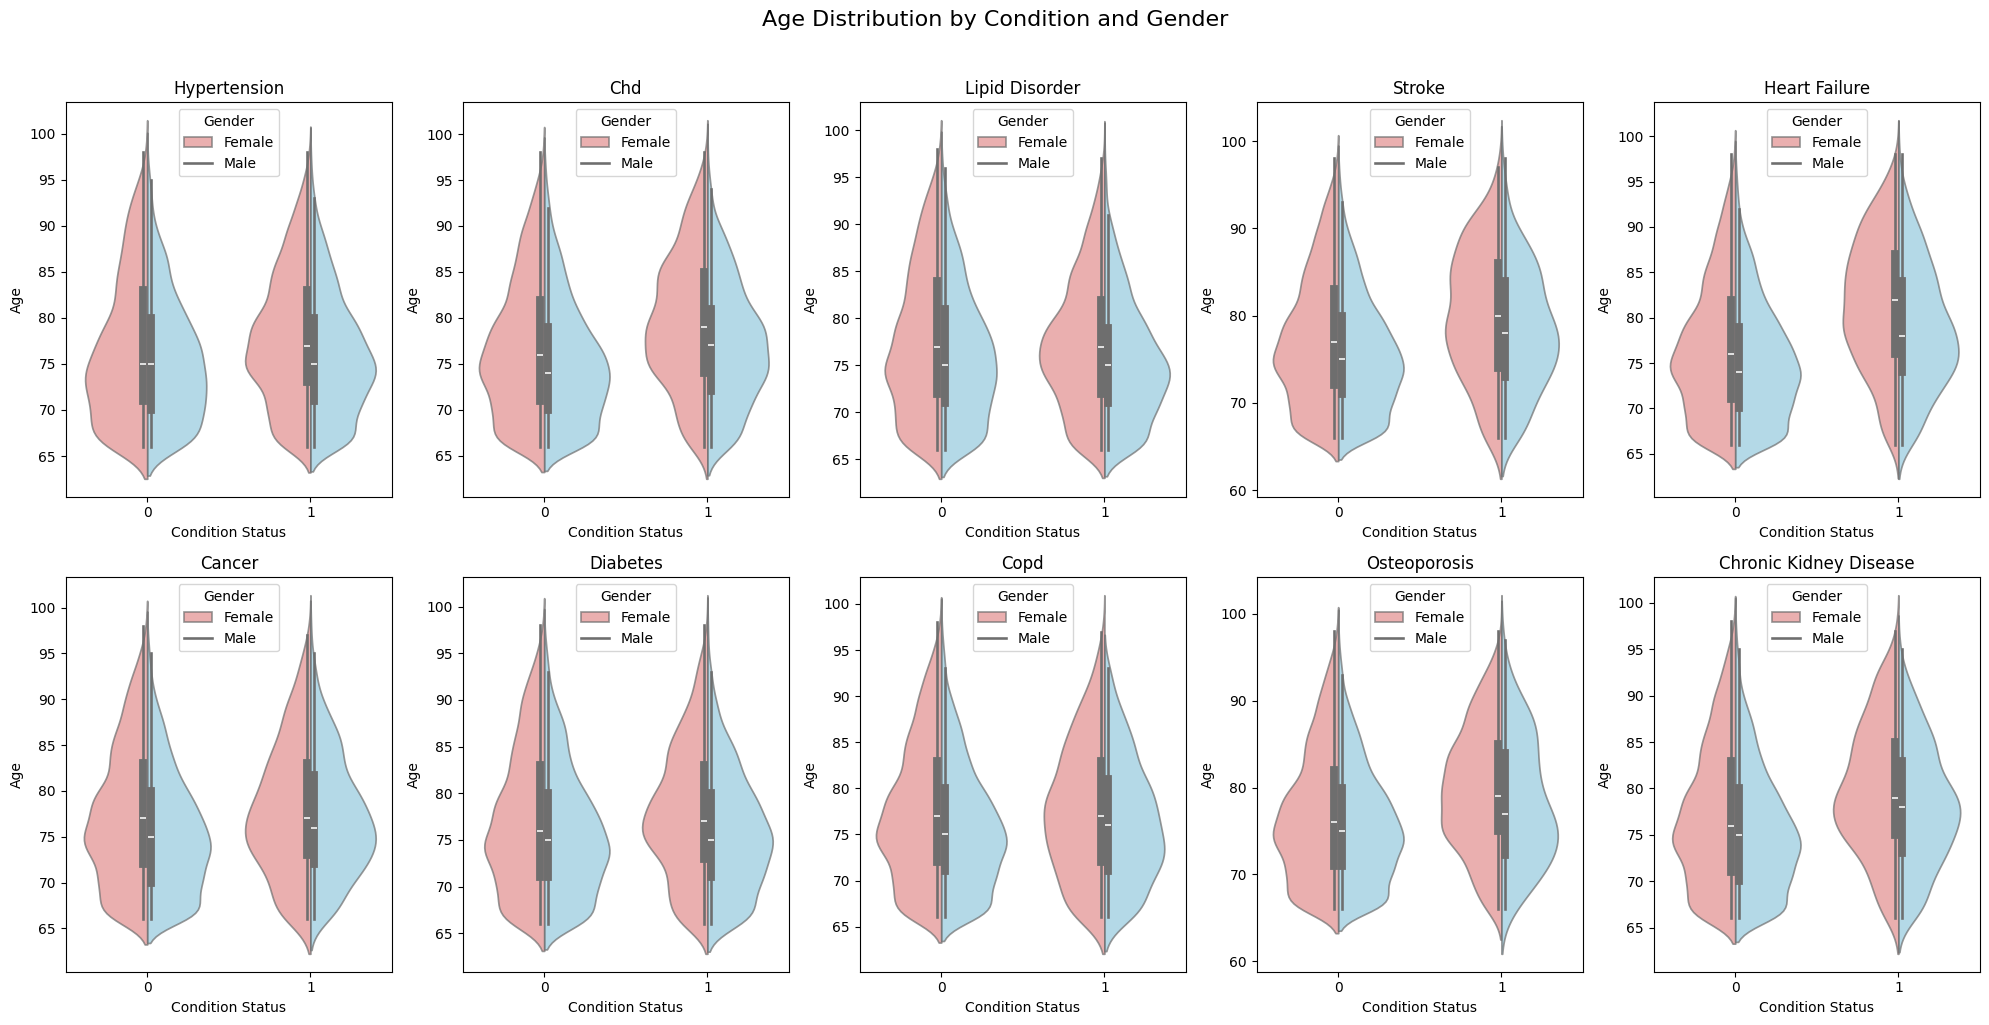

In [69]:
# List of conditions (exclude male_gender and age)
conditions = ['Hypertension', 'CHD', 'Lipid_disorder', 'Stroke', 
              'Heart_failure', 'Cancer', 'Diabetes', 'COPD', 
              'Osteoporosis', 'Chronic_kidney_disease']

# Gender-stratified violin plots for each condition
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, condition in enumerate(conditions):
    sns.violinplot(data=dropnaset, x=condition, y='age', 
                   hue='male_gender', split=True,
                   palette={0: 'lightcoral', 1: 'skyblue'},  # Fixed: use 0 and 1
                   alpha=0.7, ax=axes[idx])
    axes[idx].set_title(f'{condition.replace("_", " ").title()}')
    axes[idx].set_xlabel('Condition Status')
    axes[idx].set_ylabel('Age')
    axes[idx].legend(title='Gender', labels=['Female', 'Male'])  # Fixed: labels in order

plt.suptitle('Age Distribution by Condition and Gender', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [70]:
X = dropnaset.drop('Stroke', axis=1) # Features (excluding target)
y = dropnaset['Stroke']  # Target variable

X_train0, X_test0, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,  # Increased from 0.2 to 0.3 (30% test, 70% train)
    random_state=42,  # Remove or change this to None for different random splits each time
    stratify=y,
    shuffle=True  # Explicitly shuffle (True by default, but good to specify)
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train0)
X_test = scaler.transform(X_test0)

# Overall Combination

I'm going to use Logistic Regression, SVM, K-nn, XG Boost, and Random Forest Decision Tree to find correlation on strokes vs other CD and cancer vs other CD.

I will also try clustering (unsupervised learning).

# 1. Logistic Regression

In [71]:
print("="*70)
print("LOGISTIC REGRESSION (Using Best Parameters from Grid Search)")
print("="*70)

# Grid search finds best parameters
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=123
    ),
    lr_param_grid,
    cv=5,                    # This DOES the cross-validation
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV Recall score: {lr_grid.best_score_:.4f}")

 #Extract from grid_search results:
print(f"\nCross-Validation Results (from GridSearch):")
print(f"  Best CV Recall: {lr_grid.best_score_:.4f}")
print(f"  All CV scores: {lr_grid.cv_results_['mean_test_score'][lr_grid.best_index_:lr_grid.best_index_+1][0]:.4f}")

# Predictions on test set (using best model)
lr_pred = lr_best.predict(X_test)
lr_proba = lr_best.predict_proba(X_test)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"\nTest Set Performance (using best parameters: C={lr_grid.best_params_['C']}, solver={lr_grid.best_params_['solver']}):")
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall: {lr_recall:.4f} ★")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"  AUC: {lr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = lr_cm.ravel()
print(f"\nConfusion Matrix:")
print(lr_cm)
print(f"\nInterpretation:")
print(f"  True Positives (cancers found): {tp}")
print(f"  False Negatives (cancers MISSED): {fn} ← Most important!")
print(f"  False Positives (false alarms): {fp}")

LOGISTIC REGRESSION (Using Best Parameters from Grid Search)
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV Recall score: 0.6696

Cross-Validation Results (from GridSearch):
  Best CV Recall: 0.6696
  All CV scores: 0.6696

Test Set Performance (using best parameters: C=0.01, solver=liblinear):
  Accuracy: 0.6197
  Precision: 0.1078
  Recall: 0.6968 ★
  F1-Score: 0.1867
  AUC: 0.7145

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.61      0.75      2812
           1       0.11      0.70      0.19       188

    accuracy                           0.62      3000
   macro avg       0.54      0.66      0.47      3000
weighted avg       0.91      0.62      0.72      3000


Confusion Matrix:
[[1728 1084]
 [  57  131]]

Interpretation:
  True Positives (cancers found): 131
  False Negatives (cancers MISSED): 57 ← Most important!
  False Positives (false alar

# 2. SVM

In [72]:
print("\n" + "="*70)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*70)

# SVM with hyperparameter tuning optimized for recall
svm_param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf','sigmoid']
}

svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    svm_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)
svm_best = svm_grid.best_estimator_

print(f"\nBest parameters: {svm_grid.best_params_}")
print(f"Best CV Recall score: {svm_grid.best_score_:.4f}")

# Predictions (using best model from grid search)
svm_pred = svm_best.predict(X_test)
svm_proba = svm_best.predict_proba(X_test)[:, 1]

# Metrics
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_proba)  # Simpler!

print(f"\nTest Set Performance (using best parameters: C={svm_grid.best_params_['C']}, gamma={svm_grid.best_params_['gamma']}):")
print(f"  Accuracy: {svm_accuracy:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall: {svm_recall:.4f} ★")
print(f"  F1-Score: {svm_f1:.4f}")
print(f"  AUC: {svm_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

# Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_pred)
tn, fp, fn, tp = svm_cm.ravel()
print(f"\nConfusion Matrix:")
print(svm_cm)
print(f"\nInterpretation:")
print(f"  True Positives (strokes/cancers found): {tp}")
print(f"  False Negatives (MISSED): {fn} ← Most important!")
print(f"  False Positives (false alarms): {fp}")


SUPPORT VECTOR MACHINE (SVM)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best CV Recall score: 0.7381

Test Set Performance (using best parameters: C=0.1, gamma=1):
  Accuracy: 0.5353
  Precision: 0.0969
  Recall: 0.7713 ★
  F1-Score: 0.1722
  AUC: 0.6598

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.52      0.68      2812
           1       0.10      0.77      0.17       188

    accuracy                           0.54      3000
   macro avg       0.53      0.65      0.42      3000
weighted avg       0.92      0.54      0.65      3000


Confusion Matrix:
[[1461 1351]
 [  43  145]]

Interpretation:
  True Positives (strokes/cancers found): 145
  False Negatives (MISSED): 43 ← Most important!
  False Positives (false alarms): 1351


# 3. KNN

In [73]:
print("\n" + "="*70)
print("K-NEAREST NEIGHBORS (KNN)")
print("="*70)

# KNN with hyperparameter tuning optimized for recall
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Smaller k = higher recall (added 3,7)
    'weights': ['distance'],        # Distance weighting better for recall
    'metric': ['manhattan'],        # Manhattan often better for binary
    'p': [1],                       # p=1 is Manhattan (remove p param)
    'algorithm': ['auto'],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_

print(f"\nBest parameters: {knn_grid.best_params_}")
print(f"Best CV Recall score: {knn_grid.best_score_:.4f}")

# Predictions
knn_pred = knn_best.predict(X_test)
knn_proba = knn_best.predict_proba(X_test)[:, 1]

# Metrics
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_proba)  # Simpler!

print(f"\nTest Set Performance (using best parameters: n_neighbors={knn_grid.best_params_['n_neighbors']}, weights={knn_grid.best_params_['weights']}):")
print(f"  Accuracy: {knn_accuracy:.4f}")
print(f"  Precision: {knn_precision:.4f}")
print(f"  Recall: {knn_recall:.4f} ★")
print(f"  F1-Score: {knn_f1:.4f}")
print(f"  AUC: {knn_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

# Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_pred)
tn, fp, fn, tp = knn_cm.ravel()
print(f"\nConfusion Matrix:")
print(knn_cm)
print(f"\nInterpretation:")
print(f"  True Positives (found): {tp}")
print(f"  False Negatives (MISSED): {fn} ← Most important!")
print(f"  False Positives (false alarms): {fp}")


K-NEAREST NEIGHBORS (KNN)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best CV Recall score: 0.0456

Test Set Performance (using best parameters: n_neighbors=3, weights=distance):
  Accuracy: 0.9123
  Precision: 0.0968
  Recall: 0.0479 ★
  F1-Score: 0.0641
  AUC: 0.5377

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2812
           1       0.10      0.05      0.06       188

    accuracy                           0.91      3000
   macro avg       0.52      0.51      0.51      3000
weighted avg       0.89      0.91      0.90      3000


Confusion Matrix:
[[2728   84]
 [ 179    9]]

Interpretation:
  True Positives (found): 9
  False Negatives (MISSED): 179 ← Most important!
  False Positives (false alarms): 84


# 4. XGBoost

In [74]:
print("\n" + "="*70)
print("XGBOOST")
print("="*70)

# Calculate class weight for imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# XGBoost with hyperparameter tuning optimized for recall
xgb_param_grid = {
    'n_estimators': [100, 150, 200],     
    'max_depth': [5, 7, 9],               
    'learning_rate': [0.05, 0.1], 
    'subsample': [0.8, 0.9],            
    'colsample_bytree': [0.8, 0.9],    
    'min_child_weight': [1, 3],         
    'gamma': [0, 0.1],                      
    'reg_alpha': [0, 0.01],                 
    'reg_lambda': [1]                       
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ),
    xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

print(f"\nBest parameters: {xgb_grid.best_params_}")
print(f"Best CV Recall score: {xgb_grid.best_score_:.4f}")

# Predictions
xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)  # Simpler!

print(f"\nTest Set Performance (using best parameters):")
print(f"  Accuracy: {xgb_accuracy:.4f}")
print(f"  Precision: {xgb_precision:.4f}")
print(f"  Recall: {xgb_recall:.4f} ★")
print(f"  F1-Score: {xgb_f1:.4f}")
print(f"  AUC: {xgb_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
tn, fp, fn, tp = xgb_cm.ravel()
print(f"\nConfusion Matrix:")
print(xgb_cm)
print(f"\nInterpretation:")
print(f"  True Positives (found): {tp}")
print(f"  False Negatives (MISSED): {fn} ← Most important!")
print(f"  False Positives (false alarms): {fp}")


XGBOOST
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Best parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.8}
Best CV Recall score: 0.5171

Test Set Performance (using best parameters):
  Accuracy: 0.6657
  Precision: 0.1100
  Recall: 0.6117 ★
  F1-Score: 0.1865
  AUC: 0.6990

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79      2812
           1       0.11      0.61      0.19       188

    accuracy                           0.67      3000
   macro avg       0.54      0.64      0.49      3000
weighted avg       0.91      0.67      0.75      3000


Confusion Matrix:
[[1882  930]
 [  73  115]]

Interpretation:
  True Positives (found): 115
  False Negatives (MISSED): 73 ← Most important!
  False Positives (false alarms): 930


# 5. Random Forest

In [75]:
print("\n" + "="*70)
print("RANDOM FOREST")
print("="*70)

# Random Forest with hyperparameter tuning optimized for recall
rf_param_grid = {
    'n_estimators': [100, 150, 200],         
    'max_depth': [10, 15, 20],         
    'min_samples_split': [2, 5],             
    'min_samples_leaf': [1, 2, 4],           
    'class_weight': ['balanced']             
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV Recall score: {rf_grid.best_score_:.4f}")

# Predictions
rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)  # Simpler!

print(f"\nTest Set Performance (using best parameters):")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall: {rf_recall:.4f} ★")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  AUC: {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = rf_cm.ravel()
print(f"\nConfusion Matrix:")
print(rf_cm)
print(f"\nInterpretation:")
print(f"  True Positives (found): {tp}")
print(f"  False Negatives (MISSED): {fn} ← Most important!")
print(f"  False Positives (false alarms): {fp}")


RANDOM FOREST
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall score: 0.2095

Test Set Performance (using best parameters):
  Accuracy: 0.8357
  Precision: 0.1253
  Recall: 0.2713 ★
  F1-Score: 0.1714
  AUC: 0.6575

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2812
           1       0.13      0.27      0.17       188

    accuracy                           0.84      3000
   macro avg       0.54      0.57      0.54      3000
weighted avg       0.90      0.84      0.86      3000


Confusion Matrix:
[[2456  356]
 [ 137   51]]

Interpretation:
  True Positives (found): 51
  False Negatives (MISSED): 137 ← Most important!
  False Positives (false alarms): 356


# Visualization

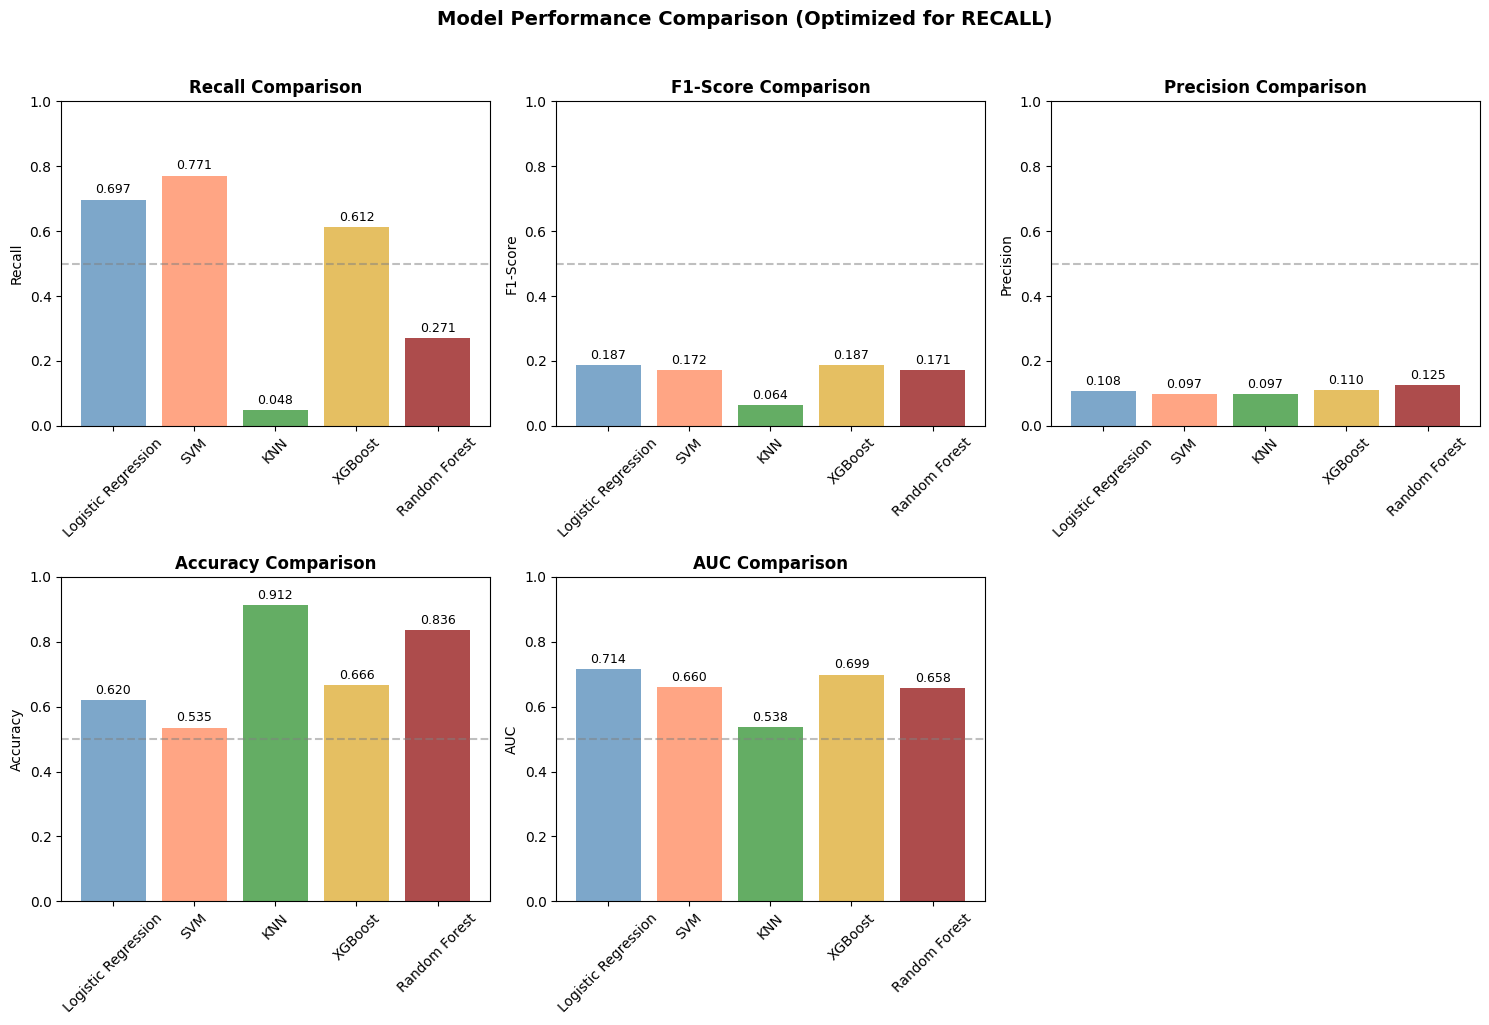

In [76]:
# Collect all results
models = ['Logistic Regression', 'SVM', 'KNN', 'XGBoost', 'Random Forest']
metrics_data = {
    'Recall': [lr_recall, svm_recall, knn_recall, xgb_recall, rf_recall],
    'F1-Score': [lr_f1, svm_f1, knn_f1, xgb_f1, rf_f1],
    'Precision': [lr_precision, svm_precision, knn_precision, xgb_precision, rf_precision],
    'Accuracy': [lr_accuracy, svm_accuracy, knn_accuracy, xgb_accuracy, rf_accuracy],
    'AUC': [lr_auc, svm_auc, knn_auc, xgb_auc, rf_auc]
}

# Create comparison plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'darkred']

for idx, (metric_name, scores) in enumerate(metrics_data.items()):
    ax = axes[idx]
    bars = ax.bar(models, scores, color=colors, alpha=0.7)
    ax.set_title(f'{metric_name} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Hide the 6th subplot if not needed
axes[5].set_visible(False)

plt.suptitle('Model Performance Comparison (Optimized for RECALL)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

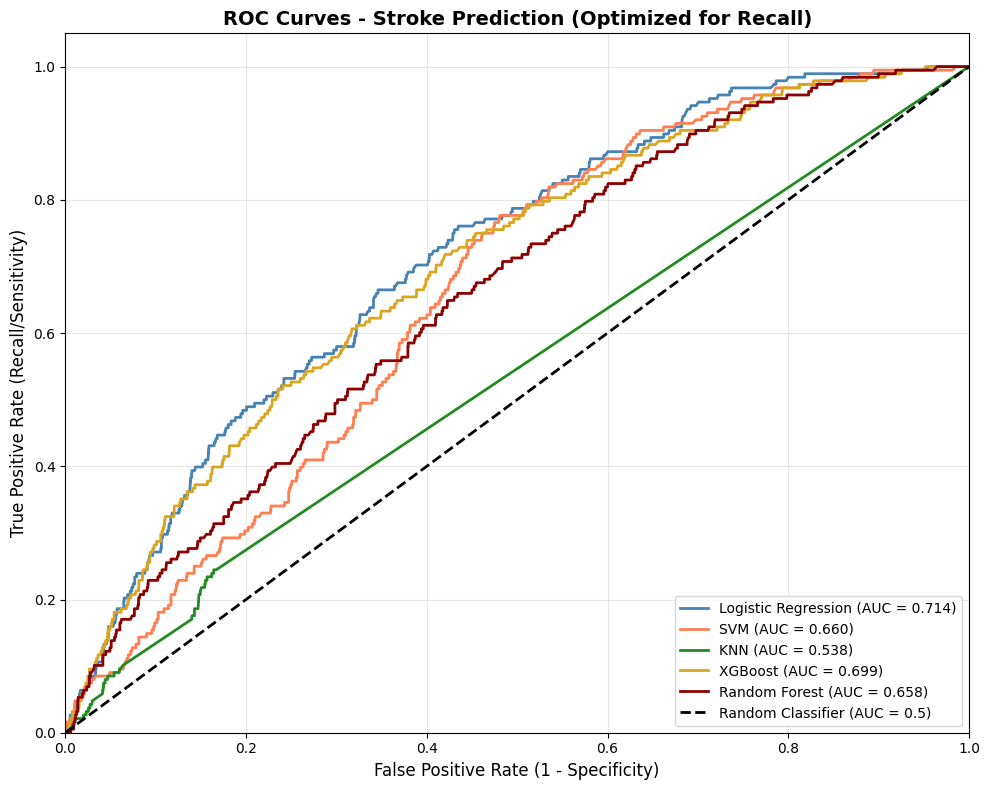

In [77]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

models_roc = [
    ('Logistic Regression', lr_proba),
    ('SVM', svm_proba),
    ('KNN', knn_proba),
    ('XGBoost', xgb_proba),
    ('Random Forest', rf_proba)
]

colors_roc = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'darkred']

for (name, proba), color in zip(models_roc, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=12)
plt.title('ROC Curves - Stroke Prediction (Optimized for Recall)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

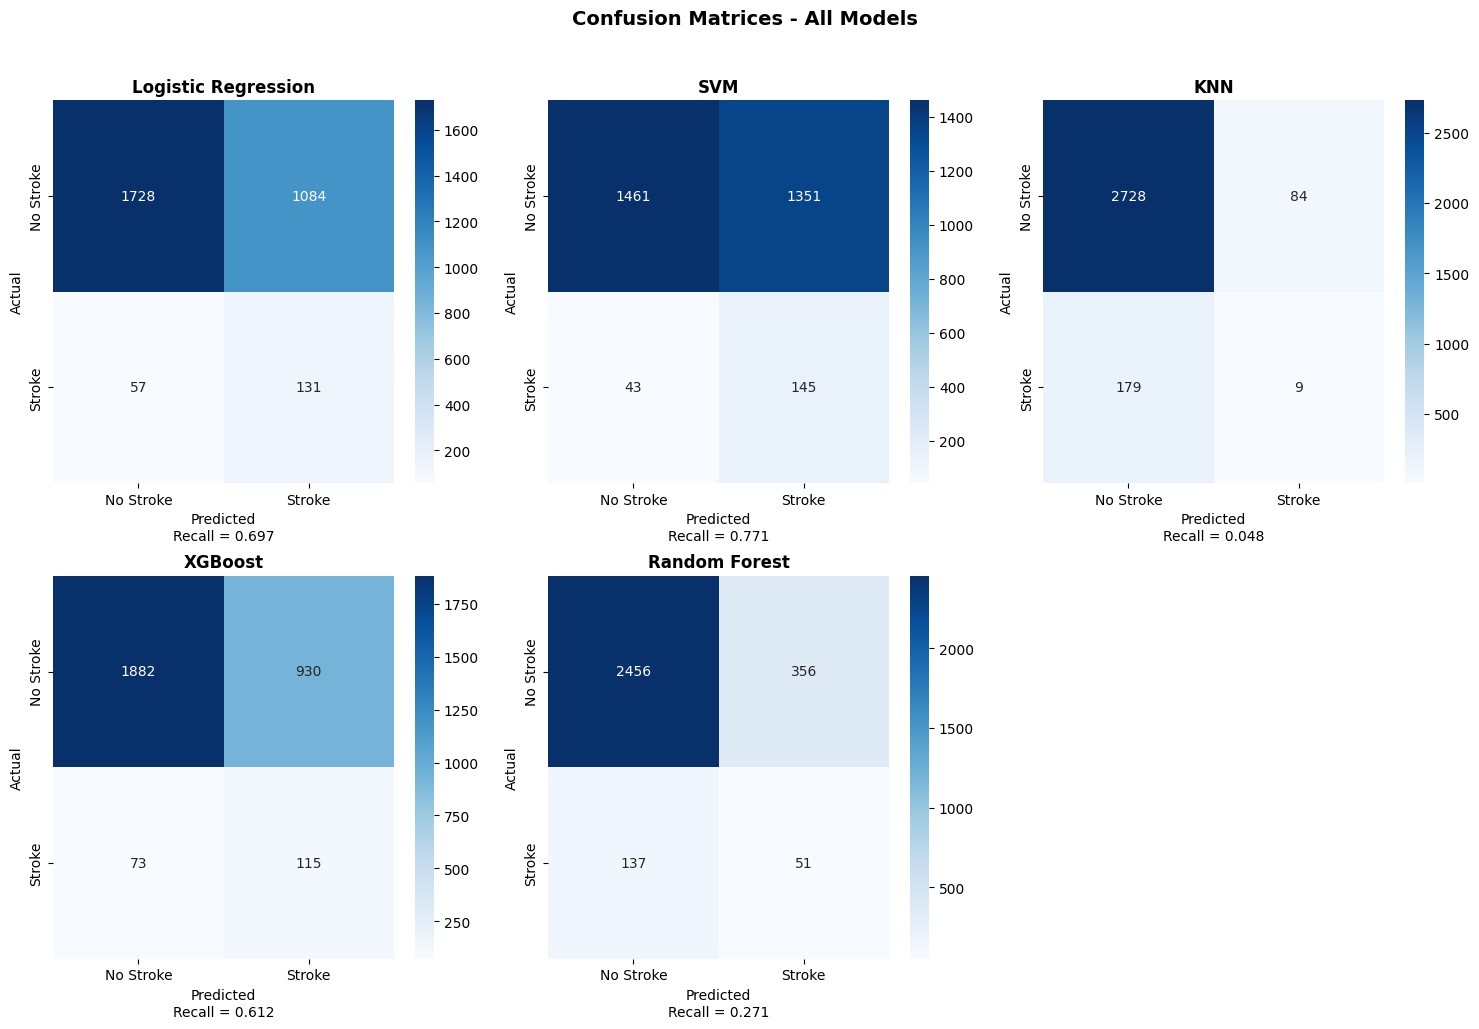

In [78]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cms = [lr_cm, svm_cm, knn_cm, xgb_cm, rf_cm]
model_names = ['Logistic Regression', 'SVM', 'KNN', 'XGBoost', 'Random Forest']

for idx, (cm, name) in enumerate(zip(cms, model_names)):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    # Add recall annotation
    recall_val = [lr_recall, svm_recall, knn_recall, xgb_recall, rf_recall][idx]
    ax.text(0.5, -0.15, f'Recall = {recall_val:.3f}', 
            transform=ax.transAxes, ha='center', fontsize=10)

axes[5].set_visible(False)
plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [79]:
# Create a summary DataFrame
summary_data = {
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'XGBoost', 'Random Forest'],
    'Recall (Test)': [lr_recall, svm_recall, knn_recall, xgb_recall, rf_recall],
    'F1-Score (Test)': [lr_f1, svm_f1, knn_f1, xgb_f1, rf_f1],
    'Precision (Test)': [lr_precision, svm_precision, knn_precision, xgb_precision, rf_precision],
    'Accuracy (Test)': [lr_accuracy, svm_accuracy, knn_accuracy, xgb_accuracy, rf_accuracy],
    'AUC (Test)': [lr_auc, svm_auc, knn_auc, xgb_auc, rf_auc],
}

# Note: You'll need to store CV results properly. Here's a cleaner way:
# Store CV results in variables during each model section:
# lr_cv_recall_mean, lr_cv_recall_std, etc.

# Print summary
print("\n" + "="*80)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*80)
print(f"\n{'Model':<20} {'Recall':<10} {'F1-Score':<10} {'Precision':<10} {'Accuracy':<10} {'AUC':<10}")
print("-"*80)
print(f"{'Logistic Regression':<20} {lr_recall:.4f}       {lr_f1:.4f}       {lr_precision:.4f}       {lr_accuracy:.4f}       {lr_auc:.4f}")
print(f"{'SVM':<20} {svm_recall:.4f}       {svm_f1:.4f}       {svm_precision:.4f}       {svm_accuracy:.4f}       {svm_auc:.4f}")
print(f"{'KNN':<20} {knn_recall:.4f}       {knn_f1:.4f}       {knn_precision:.4f}       {knn_accuracy:.4f}       {knn_auc:.4f}")
print(f"{'XGBoost':<20} {xgb_recall:.4f}       {xgb_f1:.4f}       {xgb_precision:.4f}       {xgb_accuracy:.4f}       {xgb_auc:.4f}")
print(f"{'Random Forest':<20} {rf_recall:.4f}       {rf_f1:.4f}       {rf_precision:.4f}       {rf_accuracy:.4f}       {rf_auc:.4f}")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)

# Find best model by recall
best_recall_idx = np.argmax([lr_recall, svm_recall, knn_recall, xgb_recall, rf_recall])
best_models = ['Logistic Regression', 'SVM', 'KNN', 'XGBoost', 'Random Forest']
best_recall_model = best_models[best_recall_idx]
best_recall_value = [lr_recall, svm_recall, knn_recall, xgb_recall, rf_recall][best_recall_idx]

# Find best model by F1
best_f1_idx = np.argmax([lr_f1, svm_f1, knn_f1, xgb_f1, rf_f1])
best_f1_model = best_models[best_f1_idx]
best_f1_value = [lr_f1, svm_f1, knn_f1, xgb_f1, rf_f1][best_f1_idx]

print(f"\n✓ Best for RECALL (finding strokes): {best_recall_model} (Recall = {best_recall_value:.4f})")
print(f"✓ Best for F1-SCORE (balanced performance): {best_f1_model} (F1 = {best_f1_value:.4f})")

print("\n💡 Clinical Interpretation:")
print(f"   - {best_recall_model} identifies {best_recall_value*100:.1f}% of actual strokes")
print(f"   - This means only {(1-best_recall_value)*100:.1f}% of stroke patients would be missed")
print(f"   - For stroke screening, RECALL is the most critical metric")


FINAL MODEL COMPARISON SUMMARY

Model                Recall     F1-Score   Precision  Accuracy   AUC       
--------------------------------------------------------------------------------
Logistic Regression  0.6968       0.1867       0.1078       0.6197       0.7145
SVM                  0.7713       0.1722       0.0969       0.5353       0.6598
KNN                  0.0479       0.0641       0.0968       0.9123       0.5377
XGBoost              0.6117       0.1865       0.1100       0.6657       0.6990
Random Forest        0.2713       0.1714       0.1253       0.8357       0.6575

RECOMMENDATION:

✓ Best for RECALL (finding strokes): SVM (Recall = 0.7713)
✓ Best for F1-SCORE (balanced performance): Logistic Regression (F1 = 0.1867)

💡 Clinical Interpretation:
   - SVM identifies 77.1% of actual strokes
   - This means only 22.9% of stroke patients would be missed
   - For stroke screening, RECALL is the most critical metric


# Clustering

CLUSTERING ANALYSIS - Stroke Patient Subgroups

Data shape: (10000, 11)
Features used for clustering: ['male_gender', 'age', 'Hypertension', 'CHD', 'Lipid_disorder', 'Heart_failure', 'Cancer', 'Diabetes', 'COPD', 'Osteoporosis', 'Chronic_kidney_disease']

FINDING OPTIMAL NUMBER OF CLUSTERS


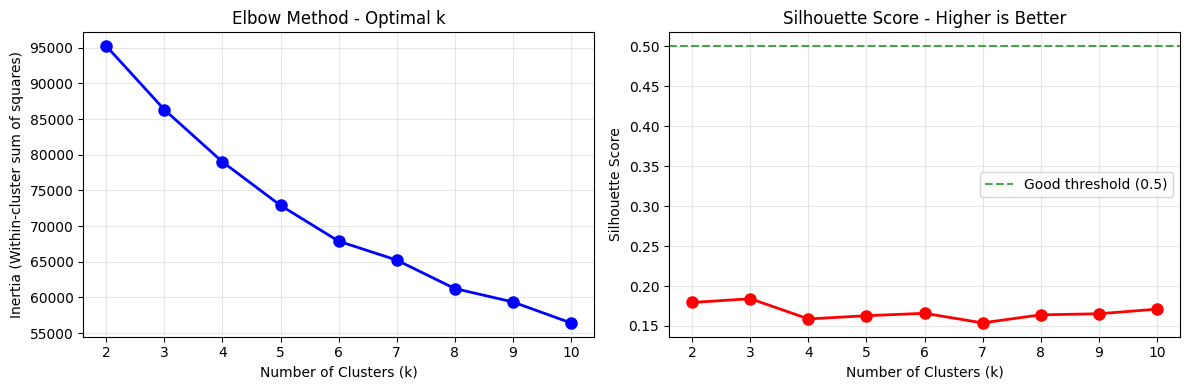


Optimal number of clusters: 3
Best silhouette score: 0.1841

APPLYING CLUSTERING ALGORITHMS

1. K-MEANS CLUSTERING

2. HIERARCHICAL CLUSTERING

3. GAUSSIAN MIXTURE MODEL

4. DBSCAN (Density-based)
   DBSCAN found 151 clusters + 1569 noise points

CLUSTERING ALGORITHM COMPARISON
Algorithm                 Silhouette Score     Clusters Found 
------------------------------------------------------------
K-Means                   0.1841                3
Hierarchical              0.2162                3
Gaussian Mixture          0.0677                3
DBSCAN                    N/A (noise points)   151

VISUALIZING CLUSTERS


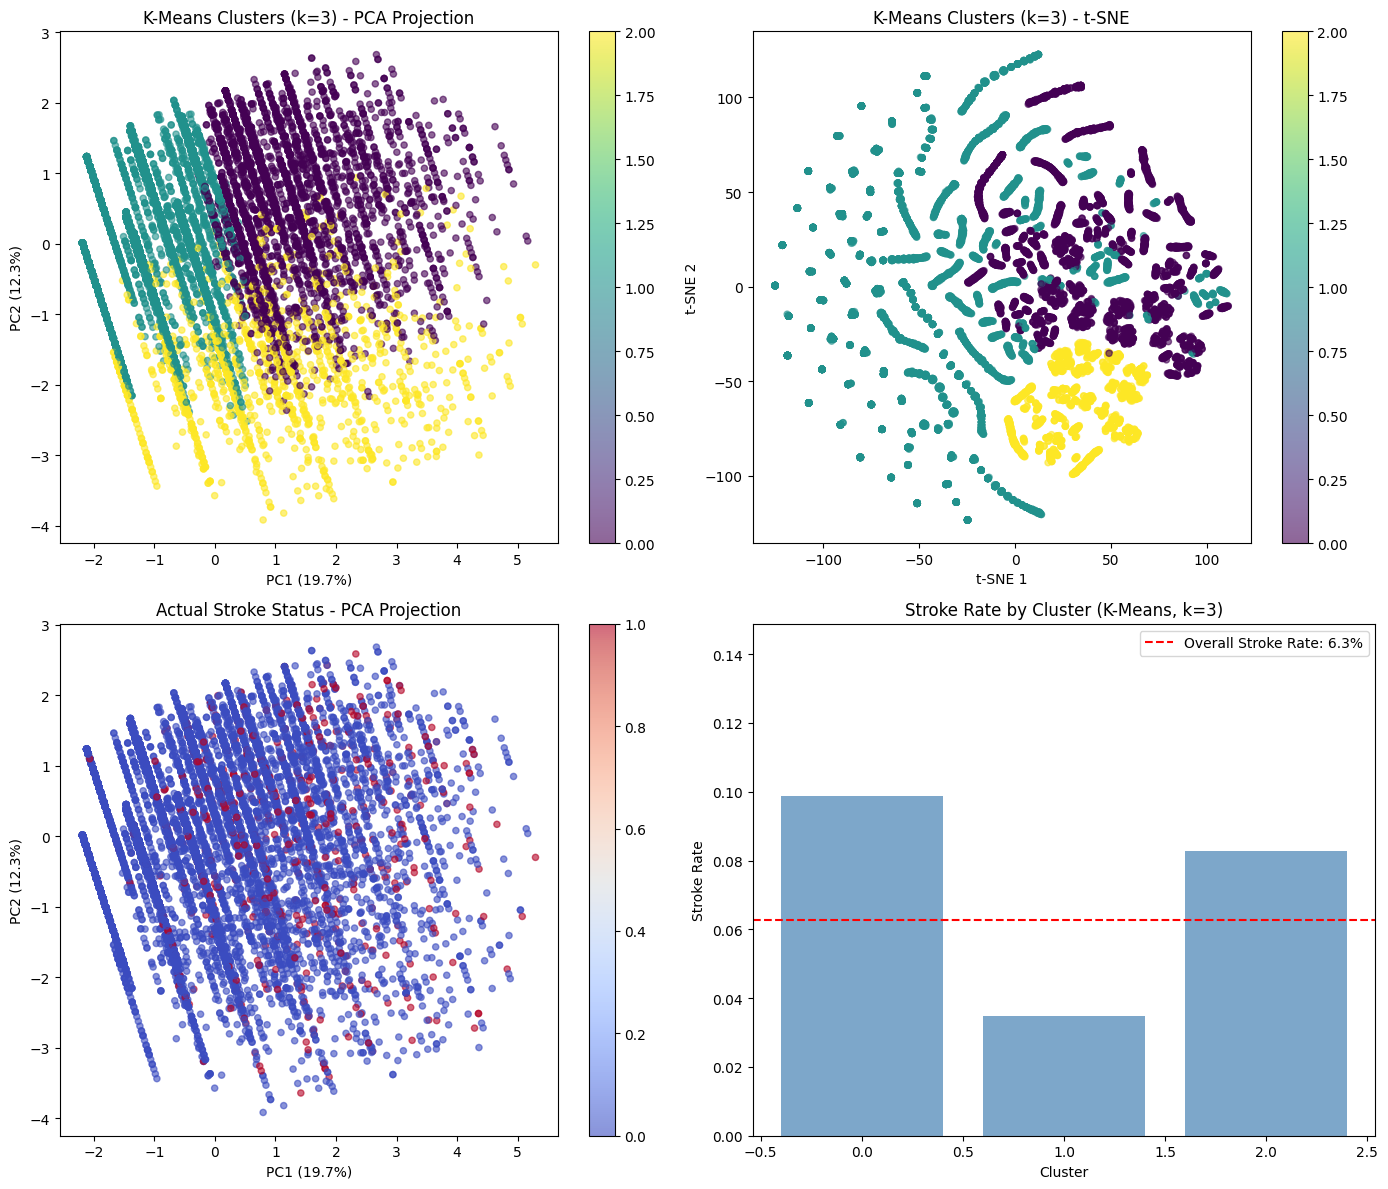


CLUSTER PROFILING (K-Means Results)

Cluster Summary:
 Cluster  Size  Size_Percent  Stroke_Rate
       0  3380         33.80     0.098817
       1  5329         53.29     0.034903
       2  1291         12.91     0.082881

KEY FINDINGS

🔴 HIGHEST STROKE RISK: Cluster 0
   Stroke Rate: 9.9%
   Patients in cluster: 3380 (33.8% of total)

🟢 LOWEST STROKE RISK: Cluster 1
   Stroke Rate: 3.5%
   Patients in cluster: 5329 (53.3% of total)


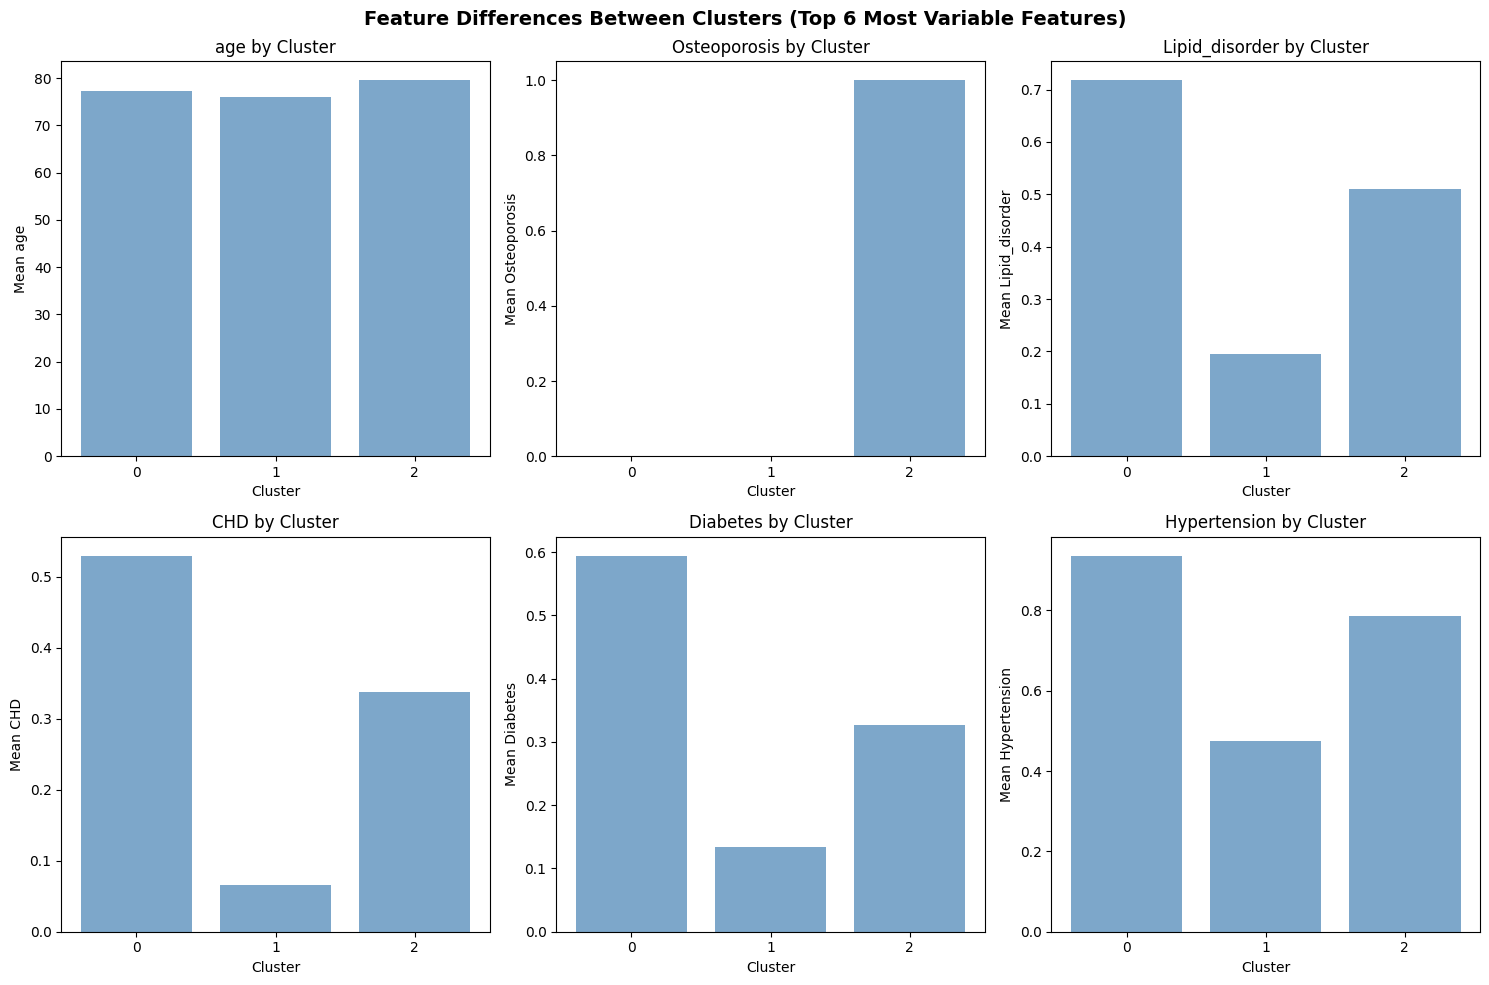


CLUSTER VALIDATION VS ACTUAL STROKE

K-Means vs Actual Stroke:
  Adjusted Rand Index: 0.0239 (1 = perfect match, 0 = random)
  Adjusted Mutual Info: 0.0128
  ⚠️ Clusters do not strongly align with stroke status (stroke risk is multifactorial)


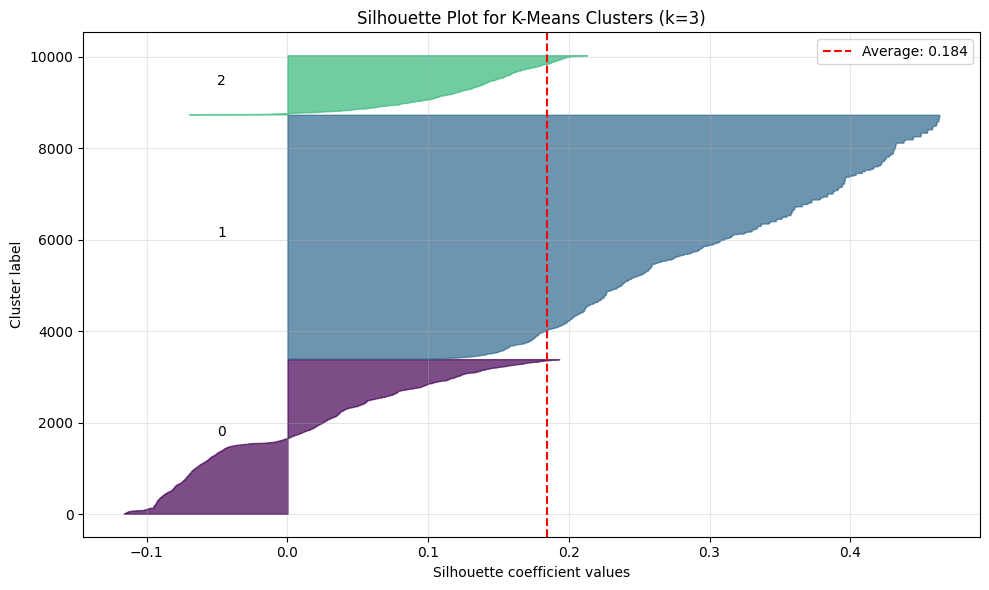


CONCLUSION

Best clustering algorithm: K-Means (silhouette = 0.1841)
Optimal number of patient subgroups: 3

✅ Clustering successfully identified high-risk subgroups!
   Cluster 0 has 9.9% stroke rate
   vs overall 6.3%

DETAILED CLUSTER ANALYSIS (3 Clusters)

CLUSTER 0: 3380 patients (33.8%)
  Average Age: 77.2 years
  Stroke Rate: 9.9%

  Disease Prevalence (%):
    Hypertension        :  93.6% ██████████████████
    CHD                 :  53.0% ██████████
    Diabetes            :  59.4% ███████████
    Heart_failure       :  31.1% ██████
    COPD                :  23.3% ████
    Osteoporosis        :   0.1% 

CLUSTER 1: 5329 patients (53.3%)
  Average Age: 76.0 years
  Stroke Rate: 3.5%

  Disease Prevalence (%):
    Hypertension        :  47.6% █████████
    CHD                 :   6.5% █
    Diabetes            :  13.4% ██
    Heart_failure       :   3.6% 
    COPD                :   4.5% 
    Osteoporosis        :   0.0% 

CLUSTER 2: 1291 patients (12.9%)
  Average Age: 79.6 ye

In [80]:
print("="*80)
print("CLUSTERING ANALYSIS - Stroke Patient Subgroups")
print("="*80)
# ============================================
# 1. PREPARE DATA (No target variable for clustering!)
# ============================================

# Features only (exclude target)
X_cluster = dropnaset.drop('Stroke', axis=1)
y_true = dropnaset['Stroke']  # For validation only

# Scale features (critical for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"\nData shape: {X_scaled.shape}")
print(f"Features used for clustering: {X_cluster.columns.tolist()}")

# ============================================
# 2. DETERMINE OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
# ============================================

print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method - Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Higher is Better')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Good threshold (0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Optimal k (where elbow occurs and silhouette is highest)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

# ============================================
# 3. APPLY CLUSTERING ALGORITHMS
# ============================================

print("\n" + "="*60)
print("APPLYING CLUSTERING ALGORITHMS")
print("="*60)

# K-Means
print("\n1. K-MEANS CLUSTERING")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

# Hierarchical/Agglomerative
print("\n2. HIERARCHICAL CLUSTERING")
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

# Gaussian Mixture Model (Soft clustering)
print("\n3. GAUSSIAN MIXTURE MODEL")
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)

# DBSCAN (automatic cluster detection)
print("\n4. DBSCAN (Density-based)")
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"   DBSCAN found {n_clusters_db} clusters + {n_noise} noise points")

# Compare clustering results
print("\n" + "="*60)
print("CLUSTERING ALGORITHM COMPARISON")
print("="*60)
print(f"{'Algorithm':<25} {'Silhouette Score':<20} {'Clusters Found':<15}")
print("-"*60)
print(f"{'K-Means':<25} {kmeans_silhouette:.4f}{' ':<15} {optimal_k}")
print(f"{'Hierarchical':<25} {hierarchical_silhouette:.4f}{' ':<15} {optimal_k}")
print(f"{'Gaussian Mixture':<25} {gmm_silhouette:.4f}{' ':<15} {optimal_k}")
if n_clusters_db > 1:
    print(f"{'DBSCAN':<25} {'N/A (noise points)':<20} {n_clusters_db}")
else:
    print(f"{'DBSCAN':<25} {'Poor clustering':<20} {n_clusters_db}")

# ============================================
# 4. VISUALIZE CLUSTERS (PCA & t-SNE)
# ============================================

print("\n" + "="*60)
print("VISUALIZING CLUSTERS")
print("="*60)

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE for better separation
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Plot clusters (using best algorithm - K-Means)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PCA - K-Means
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
axes[0, 0].set_title(f'K-Means Clusters (k={optimal_k}) - PCA Projection')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0, 0])

# t-SNE - K-Means
scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
axes[0, 1].set_title(f'K-Means Clusters (k={optimal_k}) - t-SNE')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[0, 1])

# PCA - Actual Stroke (for comparison)
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', alpha=0.6, s=20)
axes[1, 0].set_title('Actual Stroke Status - PCA Projection')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter3, ax=axes[1, 0])

# Cluster Distribution vs Stroke
cluster_stroke_prop = []
for i in range(optimal_k):
    cluster_mask = (kmeans_labels == i)
    stroke_rate = y_true[cluster_mask].mean()
    cluster_stroke_prop.append(stroke_rate)

axes[1, 1].bar(range(optimal_k), cluster_stroke_prop, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Stroke Rate')
axes[1, 1].set_title(f'Stroke Rate by Cluster (K-Means, k={optimal_k})')
axes[1, 1].axhline(y=y_true.mean(), color='red', linestyle='--', label=f'Overall Stroke Rate: {y_true.mean()*100:.1f}%')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, max(cluster_stroke_prop) + 0.05)

plt.tight_layout()
plt.show()

# ============================================
# 5. CLUSTER PROFILING - WHAT DEFINES EACH CLUSTER?
# ============================================

print("\n" + "="*60)
print("CLUSTER PROFILING (K-Means Results)")
print("="*60)

# Create cluster profile DataFrame
cluster_profile = pd.DataFrame()
cluster_profile['Cluster'] = range(optimal_k)
cluster_profile['Size'] = [np.sum(kmeans_labels == i) for i in range(optimal_k)]
cluster_profile['Size_Percent'] = cluster_profile['Size'] / len(kmeans_labels) * 100
cluster_profile['Stroke_Rate'] = cluster_stroke_prop

# Feature means by cluster
feature_columns = X_cluster.columns
for col in feature_columns:
    cluster_profile[f'Mean_{col}'] = [X_cluster.iloc[kmeans_labels == i][col].mean() for i in range(optimal_k)]

print("\nCluster Summary:")
print(cluster_profile[['Cluster', 'Size', 'Size_Percent', 'Stroke_Rate']].to_string(index=False))

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Find highest and lowest stroke risk clusters
highest_risk = cluster_profile.loc[cluster_profile['Stroke_Rate'].idxmax()]
lowest_risk = cluster_profile.loc[cluster_profile['Stroke_Rate'].idxmin()]

print(f"\n🔴 HIGHEST STROKE RISK: Cluster {int(highest_risk['Cluster'])}")
print(f"   Stroke Rate: {highest_risk['Stroke_Rate']*100:.1f}%")
print(f"   Patients in cluster: {int(highest_risk['Size'])} ({highest_risk['Size_Percent']:.1f}% of total)")

print(f"\n🟢 LOWEST STROKE RISK: Cluster {int(lowest_risk['Cluster'])}")
print(f"   Stroke Rate: {lowest_risk['Stroke_Rate']*100:.1f}%")
print(f"   Patients in cluster: {int(lowest_risk['Size'])} ({lowest_risk['Size_Percent']:.1f}% of total)")

# ============================================
# 6. VISUALIZE FEATURE DIFFERENCES BETWEEN CLUSTERS
# ============================================

# Top features that differ most between clusters
feature_means = cluster_profile[[f'Mean_{col}' for col in feature_columns]]
feature_ranges = feature_means.max() - feature_means.min()
top_features = feature_ranges.nlargest(6).index
top_features_names = [f.replace('Mean_', '') for f in top_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (feature, feature_name) in enumerate(zip(top_features, top_features_names)):
    ax = axes[idx]
    means = cluster_profile[feature].values
    ax.bar(range(optimal_k), means, color='steelblue', alpha=0.7)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(f'Mean {feature_name}')
    ax.set_title(f'{feature_name} by Cluster')
    ax.set_xticks(range(optimal_k))

plt.suptitle('Feature Differences Between Clusters (Top 6 Most Variable Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. CLUSTER VALIDATION - DO CLUSTERS ALIGN WITH STROKE?
# ============================================

print("\n" + "="*60)
print("CLUSTER VALIDATION VS ACTUAL STROKE")
print("="*60)

# Adjusted Rand Index (how well clusters match actual stroke labels)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)
ami_kmeans = adjusted_mutual_info_score(y_true, kmeans_labels)

print(f"\nK-Means vs Actual Stroke:")
print(f"  Adjusted Rand Index: {ari_kmeans:.4f} (1 = perfect match, 0 = random)")
print(f"  Adjusted Mutual Info: {ami_kmeans:.4f}")

if ari_kmeans > 0.1:
    print("  ✅ Clusters have some alignment with stroke status")
else:
    print("  ⚠️ Clusters do not strongly align with stroke status (stroke risk is multifactorial)")

# ============================================
# 8. SILHOUETTE ANALYSIS FOR EACH CLUSTER
# ============================================
silhouette_vals = silhouette_samples(X_scaled, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(optimal_k):
    ith_cluster_silhouette_vals = silhouette_vals[kmeans_labels == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    color = plt.cm.viridis(float(i) / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax.axvline(x=kmeans_silhouette, color="red", linestyle="--", label=f'Average: {kmeans_silhouette:.3f}')
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.set_title(f"Silhouette Plot for K-Means Clusters (k={optimal_k})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print(f"\nBest clustering algorithm: K-Means (silhouette = {kmeans_silhouette:.4f})")
print(f"Optimal number of patient subgroups: {optimal_k}")

if max(cluster_stroke_prop) > y_true.mean() * 1.5:
    print(f"\n✅ Clustering successfully identified high-risk subgroups!")
    print(f"   Cluster {int(highest_risk['Cluster'])} has {highest_risk['Stroke_Rate']*100:.1f}% stroke rate")
    print(f"   vs overall {y_true.mean()*100:.1f}%")
else:
    print(f"\n⚠️ While clusters exist, stroke risk is distributed across subgroups")
    print(f"   This suggests stroke is influenced by complex, non-linear combinations of factors")
    
    
# ============================================
# DETAILED 3-CLUSTER ANALYSIS
# ============================================

print("\n" + "="*60)
print("DETAILED CLUSTER ANALYSIS (3 Clusters)")
print("="*60)

# Get cluster sizes and basic stats
for i in range(optimal_k):
    cluster_mask = (kmeans_labels == i)
    size = cluster_mask.sum()
    pct = size / len(kmeans_labels) * 100
    
    # Disease rates
    stroke_rate = y_true[cluster_mask].mean() * 100
    
    # Age (since you included it)
    avg_age = dropnaset.loc[cluster_mask, 'age'].mean()
    
    print(f"\n{'='*50}")
    print(f"CLUSTER {i}: {size} patients ({pct:.1f}%)")
    print(f"{'='*50}")
    print(f"  Average Age: {avg_age:.1f} years")
    print(f"  Stroke Rate: {stroke_rate:.1f}%")
    
    # Disease profile
    print(f"\n  Disease Prevalence (%):")
    for disease in ['Hypertension', 'CHD', 'Diabetes', 'Heart_failure', 'COPD', 'Osteoporosis']:
        rate = dropnaset.loc[cluster_mask, disease].mean() * 100
        bar = '█' * int(rate / 5)
        print(f"    {disease:20s}: {rate:5.1f}% {bar}")

# Calculate risk ratios
print("\n" + "="*60)
print("RISK RATIOS (Compared to Population Average)")
print("="*60)

overall_stroke = y_true.mean() * 100

for i in range(optimal_k):
    cluster_mask = (kmeans_labels == i)
    stroke_ratio = (y_true[cluster_mask].mean() * 100) / overall_stroke
    
    print(f"\nCluster {i}:")
    print(f"  Stroke Risk Ratio: {stroke_ratio:.2f}x {'↑' if stroke_ratio > 1 else '↓'}")

### Without age.

CLUSTERING ANALYSIS - Stroke Patient Subgroups

Data shape: (10000, 10)
Features used for clustering: ['male_gender', 'Hypertension', 'CHD', 'Lipid_disorder', 'Heart_failure', 'Cancer', 'Diabetes', 'COPD', 'Osteoporosis', 'Chronic_kidney_disease']

FINDING OPTIMAL NUMBER OF CLUSTERS


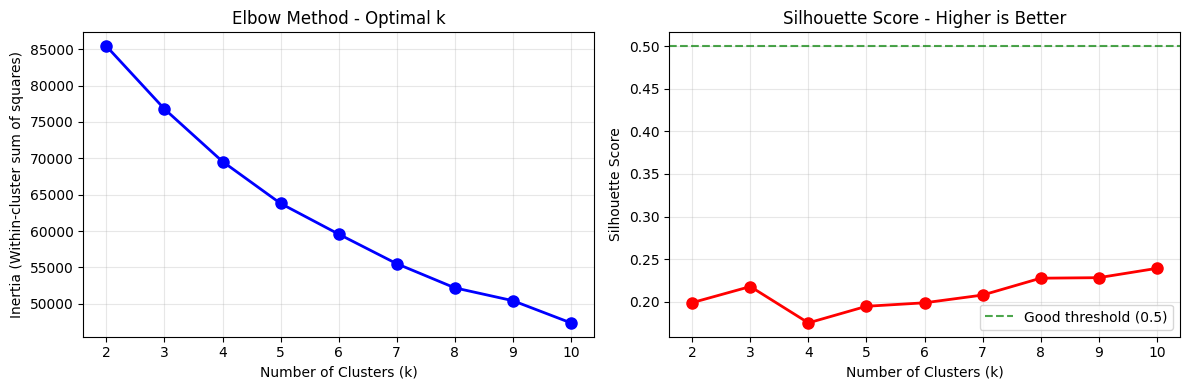


Optimal number of clusters: 10
Best silhouette score: 0.2392

APPLYING CLUSTERING ALGORITHMS

1. K-MEANS CLUSTERING

2. HIERARCHICAL CLUSTERING

3. GAUSSIAN MIXTURE MODEL

4. DBSCAN (Density-based)
   DBSCAN found 158 clusters + 1475 noise points

CLUSTERING ALGORITHM COMPARISON
Algorithm                 Silhouette Score     Clusters Found 
------------------------------------------------------------
K-Means                   0.2392                10
Hierarchical              0.2388                10
Gaussian Mixture          0.2176                10
DBSCAN                    N/A (noise points)   158

VISUALIZING CLUSTERS


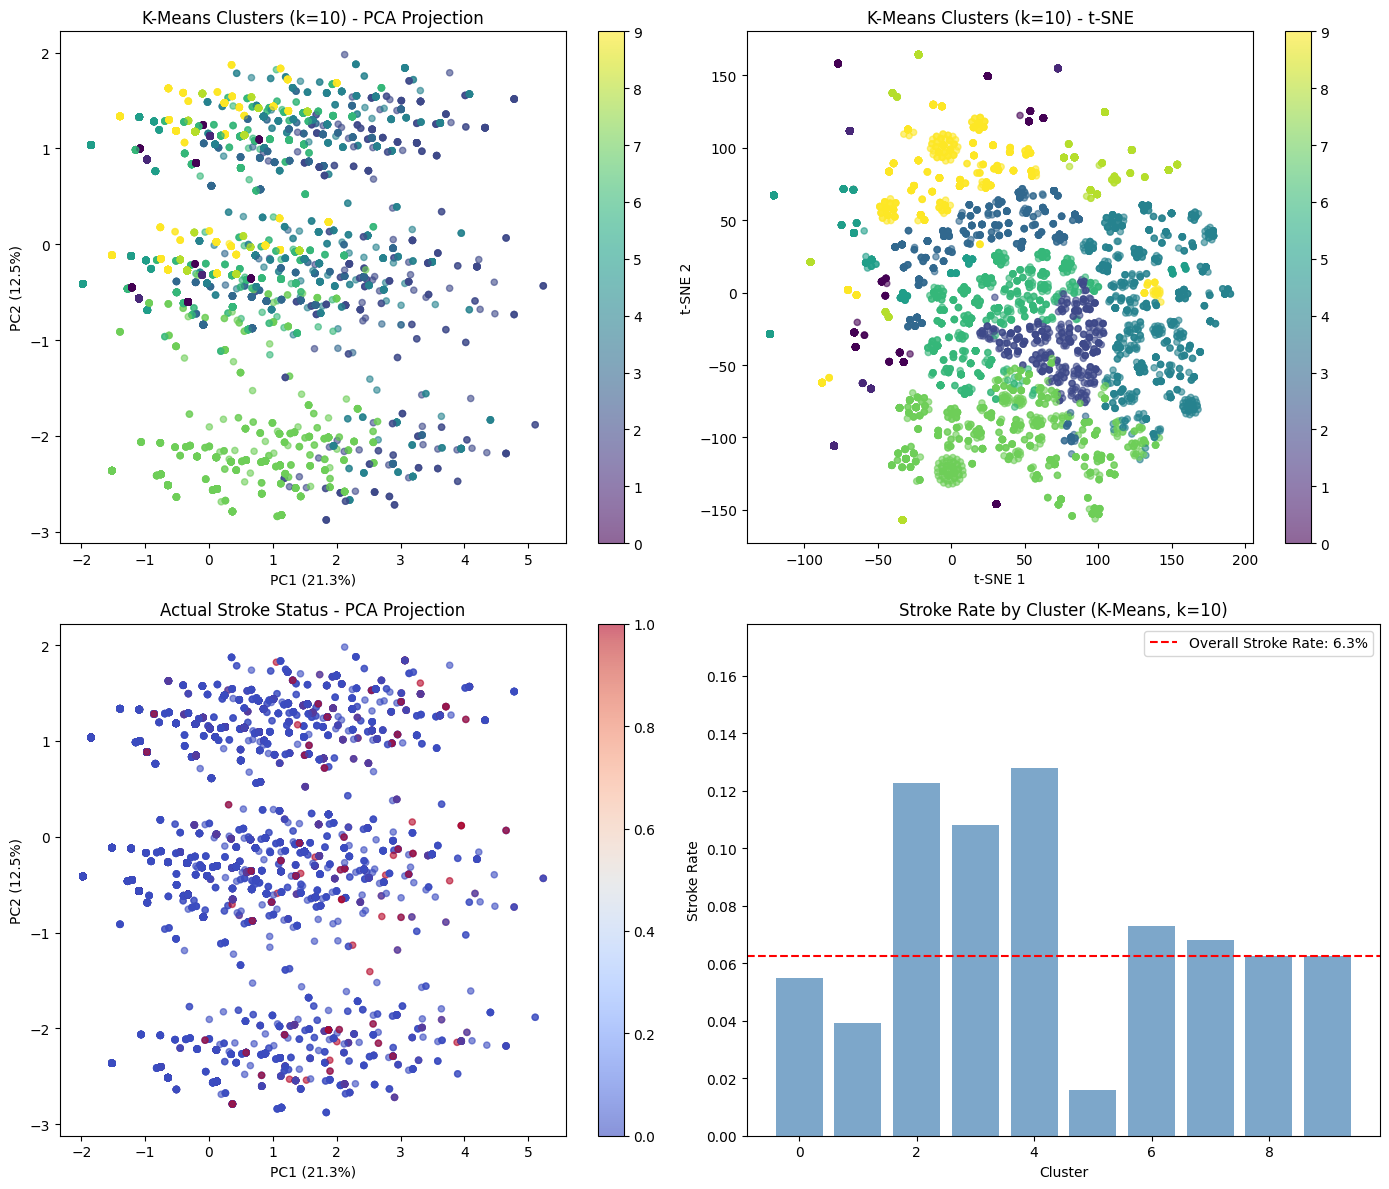


CLUSTER PROFILING (K-Means Results)

Cluster Summary:
 Cluster  Size  Size_Percent  Stroke_Rate
       0  1113         11.13     0.054807
       1  1201         12.01     0.039134
       2   407          4.07     0.122850
       3   648          6.48     0.108025
       4   929          9.29     0.128095
       5  1937         19.37     0.016004
       6   755          7.55     0.072848
       7  1027         10.27     0.068160
       8  1088         10.88     0.062500
       9   895          8.95     0.062570

KEY FINDINGS

🔴 HIGHEST STROKE RISK: Cluster 4
   Stroke Rate: 12.8%
   Patients in cluster: 929 (9.3% of total)

🟢 LOWEST STROKE RISK: Cluster 5
   Stroke Rate: 1.6%
   Patients in cluster: 1937 (19.4% of total)


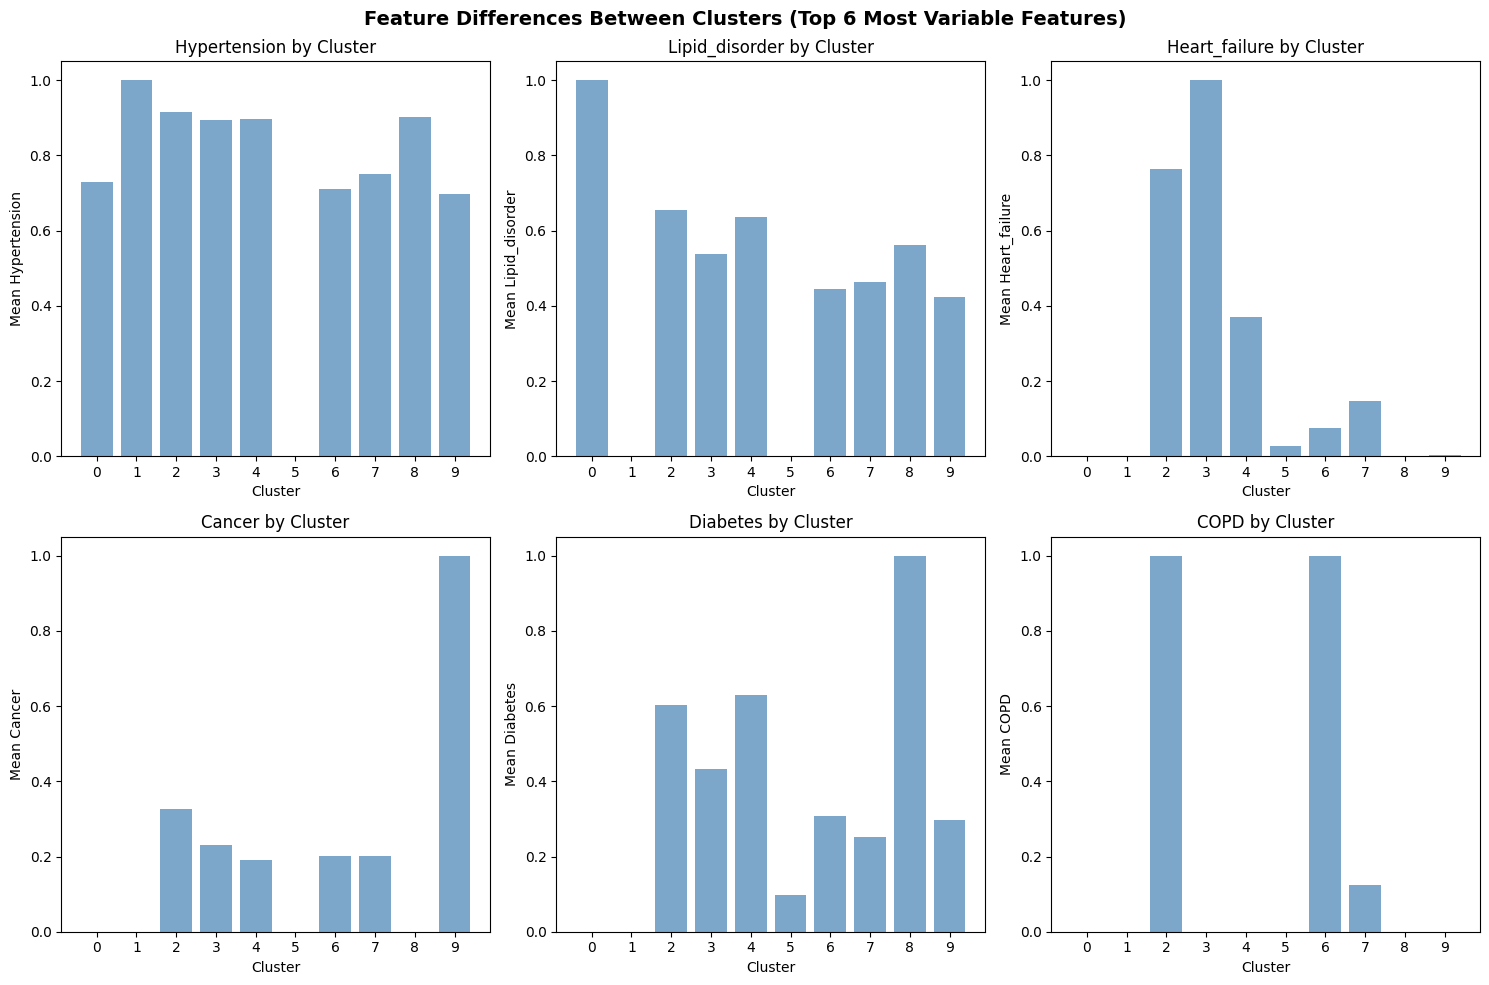


CLUSTER VALIDATION VS ACTUAL STROKE

K-Means vs Actual Stroke:
  Adjusted Rand Index: 0.0061 (1 = perfect match, 0 = random)
  Adjusted Mutual Info: 0.0081
  ⚠️ Clusters do not strongly align with stroke status (stroke risk is multifactorial)


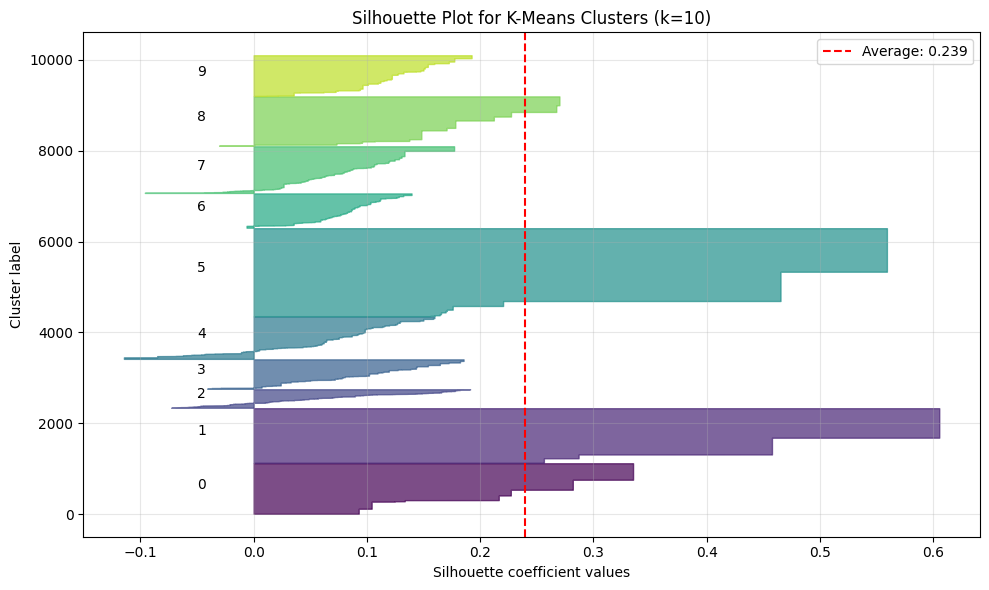


CONCLUSION

Best clustering algorithm: K-Means (silhouette = 0.2392)
Optimal number of patient subgroups: 10

✅ Clustering successfully identified high-risk subgroups!
   Cluster 4 has 12.8% stroke rate
   vs overall 6.3%


In [81]:
print("="*80)
print("CLUSTERING ANALYSIS - Stroke Patient Subgroups")
print("="*80)
# ============================================
# 1. PREPARE DATA (No target variable for clustering!)
# ============================================

# Features only (exclude target)
X_cluster = binaryset.drop('Stroke', axis=1)
y_true = binaryset['Stroke']  # For validation only

# Scale features (critical for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"\nData shape: {X_scaled.shape}")
print(f"Features used for clustering: {X_cluster.columns.tolist()}")

# ============================================
# 2. DETERMINE OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
# ============================================

print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method - Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Higher is Better')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Good threshold (0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Optimal k (where elbow occurs and silhouette is highest)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

# ============================================
# 3. APPLY CLUSTERING ALGORITHMS
# ============================================

print("\n" + "="*60)
print("APPLYING CLUSTERING ALGORITHMS")
print("="*60)

# K-Means
print("\n1. K-MEANS CLUSTERING")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

# Hierarchical/Agglomerative
print("\n2. HIERARCHICAL CLUSTERING")
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

# Gaussian Mixture Model (Soft clustering)
print("\n3. GAUSSIAN MIXTURE MODEL")
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)

# DBSCAN (automatic cluster detection)
print("\n4. DBSCAN (Density-based)")
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"   DBSCAN found {n_clusters_db} clusters + {n_noise} noise points")

# Compare clustering results
print("\n" + "="*60)
print("CLUSTERING ALGORITHM COMPARISON")
print("="*60)
print(f"{'Algorithm':<25} {'Silhouette Score':<20} {'Clusters Found':<15}")
print("-"*60)
print(f"{'K-Means':<25} {kmeans_silhouette:.4f}{' ':<15} {optimal_k}")
print(f"{'Hierarchical':<25} {hierarchical_silhouette:.4f}{' ':<15} {optimal_k}")
print(f"{'Gaussian Mixture':<25} {gmm_silhouette:.4f}{' ':<15} {optimal_k}")
if n_clusters_db > 1:
    print(f"{'DBSCAN':<25} {'N/A (noise points)':<20} {n_clusters_db}")
else:
    print(f"{'DBSCAN':<25} {'Poor clustering':<20} {n_clusters_db}")

# ============================================
# 4. VISUALIZE CLUSTERS (PCA & t-SNE)
# ============================================

print("\n" + "="*60)
print("VISUALIZING CLUSTERS")
print("="*60)

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE for better separation
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Plot clusters (using best algorithm - K-Means)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PCA - K-Means
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
axes[0, 0].set_title(f'K-Means Clusters (k={optimal_k}) - PCA Projection')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0, 0])

# t-SNE - K-Means
scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
axes[0, 1].set_title(f'K-Means Clusters (k={optimal_k}) - t-SNE')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[0, 1])

# PCA - Actual Stroke (for comparison)
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', alpha=0.6, s=20)
axes[1, 0].set_title('Actual Stroke Status - PCA Projection')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter3, ax=axes[1, 0])

# Cluster Distribution vs Stroke
cluster_stroke_prop = []
for i in range(optimal_k):
    cluster_mask = (kmeans_labels == i)
    stroke_rate = y_true[cluster_mask].mean()
    cluster_stroke_prop.append(stroke_rate)

axes[1, 1].bar(range(optimal_k), cluster_stroke_prop, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Stroke Rate')
axes[1, 1].set_title(f'Stroke Rate by Cluster (K-Means, k={optimal_k})')
axes[1, 1].axhline(y=y_true.mean(), color='red', linestyle='--', label=f'Overall Stroke Rate: {y_true.mean()*100:.1f}%')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, max(cluster_stroke_prop) + 0.05)

plt.tight_layout()
plt.show()

# ============================================
# 5. CLUSTER PROFILING - WHAT DEFINES EACH CLUSTER?
# ============================================

print("\n" + "="*60)
print("CLUSTER PROFILING (K-Means Results)")
print("="*60)

# Create cluster profile DataFrame
cluster_profile = pd.DataFrame()
cluster_profile['Cluster'] = range(optimal_k)
cluster_profile['Size'] = [np.sum(kmeans_labels == i) for i in range(optimal_k)]
cluster_profile['Size_Percent'] = cluster_profile['Size'] / len(kmeans_labels) * 100
cluster_profile['Stroke_Rate'] = cluster_stroke_prop

# Feature means by cluster
feature_columns = X_cluster.columns
for col in feature_columns:
    cluster_profile[f'Mean_{col}'] = [X_cluster.iloc[kmeans_labels == i][col].mean() for i in range(optimal_k)]

print("\nCluster Summary:")
print(cluster_profile[['Cluster', 'Size', 'Size_Percent', 'Stroke_Rate']].to_string(index=False))

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Find highest and lowest stroke risk clusters
highest_risk = cluster_profile.loc[cluster_profile['Stroke_Rate'].idxmax()]
lowest_risk = cluster_profile.loc[cluster_profile['Stroke_Rate'].idxmin()]

print(f"\n🔴 HIGHEST STROKE RISK: Cluster {int(highest_risk['Cluster'])}")
print(f"   Stroke Rate: {highest_risk['Stroke_Rate']*100:.1f}%")
print(f"   Patients in cluster: {int(highest_risk['Size'])} ({highest_risk['Size_Percent']:.1f}% of total)")

print(f"\n🟢 LOWEST STROKE RISK: Cluster {int(lowest_risk['Cluster'])}")
print(f"   Stroke Rate: {lowest_risk['Stroke_Rate']*100:.1f}%")
print(f"   Patients in cluster: {int(lowest_risk['Size'])} ({lowest_risk['Size_Percent']:.1f}% of total)")

# ============================================
# 6. VISUALIZE FEATURE DIFFERENCES BETWEEN CLUSTERS
# ============================================

# Top features that differ most between clusters
feature_means = cluster_profile[[f'Mean_{col}' for col in feature_columns]]
feature_ranges = feature_means.max() - feature_means.min()
top_features = feature_ranges.nlargest(6).index
top_features_names = [f.replace('Mean_', '') for f in top_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (feature, feature_name) in enumerate(zip(top_features, top_features_names)):
    ax = axes[idx]
    means = cluster_profile[feature].values
    ax.bar(range(optimal_k), means, color='steelblue', alpha=0.7)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(f'Mean {feature_name}')
    ax.set_title(f'{feature_name} by Cluster')
    ax.set_xticks(range(optimal_k))

plt.suptitle('Feature Differences Between Clusters (Top 6 Most Variable Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. CLUSTER VALIDATION - DO CLUSTERS ALIGN WITH STROKE?
# ============================================

print("\n" + "="*60)
print("CLUSTER VALIDATION VS ACTUAL STROKE")
print("="*60)

# Adjusted Rand Index (how well clusters match actual stroke labels)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)
ami_kmeans = adjusted_mutual_info_score(y_true, kmeans_labels)

print(f"\nK-Means vs Actual Stroke:")
print(f"  Adjusted Rand Index: {ari_kmeans:.4f} (1 = perfect match, 0 = random)")
print(f"  Adjusted Mutual Info: {ami_kmeans:.4f}")

if ari_kmeans > 0.1:
    print("  ✅ Clusters have some alignment with stroke status")
else:
    print("  ⚠️ Clusters do not strongly align with stroke status (stroke risk is multifactorial)")

# ============================================
# 8. SILHOUETTE ANALYSIS FOR EACH CLUSTER
# ============================================
silhouette_vals = silhouette_samples(X_scaled, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(optimal_k):
    ith_cluster_silhouette_vals = silhouette_vals[kmeans_labels == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    color = plt.cm.viridis(float(i) / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax.axvline(x=kmeans_silhouette, color="red", linestyle="--", label=f'Average: {kmeans_silhouette:.3f}')
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.set_title(f"Silhouette Plot for K-Means Clusters (k={optimal_k})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print(f"\nBest clustering algorithm: K-Means (silhouette = {kmeans_silhouette:.4f})")
print(f"Optimal number of patient subgroups: {optimal_k}")

if max(cluster_stroke_prop) > y_true.mean() * 1.5:
    print(f"\n✅ Clustering successfully identified high-risk subgroups!")
    print(f"   Cluster {int(highest_risk['Cluster'])} has {highest_risk['Stroke_Rate']*100:.1f}% stroke rate")
    print(f"   vs overall {y_true.mean()*100:.1f}%")
else:
    print(f"\n⚠️ While clusters exist, stroke risk is distributed across subgroups")
    print(f"   This suggests stroke is influenced by complex, non-linear combinations of factors")